# Статистический анализ данных
---
(лекции 4 часа, практика 6 часов)

- Модели зависимости двух величин. Анализ парных зависимостей.
- Линейная зависимость. Построение линейной зависимости.
- Понятие корреляции. Оценка силы линейной зависимости.
- Коэффициенты корреляций: коэффициент Пирсона, коэффициент Спирмена, коэффициент Кендалла, условия применения каждого коэффициента.
- Роль корреляционного анализа. Примеры применения в образовании


## **1. Модели зависимости двух величин. Анализ парных зависимостей**
---

Модели зависимости двух величин (парная регрессия) — это математические инструменты, описывающие влияние одной независимой переменной (x) на зависимую (y). Они включают линейные, степенные и экспоненциальные формы, определяемые методами корреляционно - регрессионного анализа для прогнозирования и оценки силы связи.

Анализ парных зависимостей (Регрессионный анализ)

Виды зависимостей:
- Линейная ($y=a + bx$): Самая простая, прямая связь.

- Нелинейная:
- - Степенная ($y = a \cdot x^b$),
- - экспоненциальная ($y = a \cdot e^{bx}$),
- - логарифмическая ($y = a + b \cdot ln(x)$),
- - полиномиальная $y = a_0 + \sum_{i=1}^m {a_i \cdot ϕ_i(x)}$, линейная комбинация различных базисных функций.

**Этапы анализа:**

- Постановка задачи: Выбор зависимой (y) и независимой (x) переменной.

- Визуализация: Построение диаграммы рассеяния (scatterplot) для определения формы зависимости.

- Построение модели: Определение коэффициентов (a и b) методом наименьших квадратов (МНК).

- Оценка качества: Использование коэффициента детерминации ($R^2$) для определения доли объясненной дисперсии.

- Интерпретация: Коэффициент регрессии b показывает, насколько изменится y при изменении x на единицу.

**Корреляционный анализ:**

- Определяет силу и направление связи (коэффициент корреляции Пирсона).
- Значения коэффициента корреляции от -1 до 1: чем ближе к 1 или -1, тем сильнее связь.

**Значимость модели:**

- Проверка значимости регрессии с помощью F-теста или t-теста для коэффициентов.

- Если p-value коэффициента меньше 0,05, связь считается статистически значимой.

In [4]:
# импорт необходимых библиотек работы с данными
import numpy as np
np.set_printoptions(precision=3)
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# подключение гугл-диска к среде colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **2. Линейная зависимость. Построение линейной заивисимости**
---

Начнем анализ с построения самой простой линейной связи:
$$y=a + bx$$

### ПРИМЕР 3.1.
---
Проиллюстрируем построение простой линейной связи на примере.

В начале курса по математике для первокурсников преподаватли часть проводят предварительнее тестирование, чтобы понять - насколько поток готов к курсу и какой уровень изложения материала выбрать.

Нас будет интересовать вопрос, насколько уровень подготовки обучающихся влияет на итоговый балл курса

В качестве исходных данных рассмотрим результаты обучения потока студентов направления "Программная инженерия" на 1-м курсе по предмету "Линейная алгебра"

In [5]:
# DIR PATH to DATA
dir_path = "/content/drive/My Drive/Colab Notebooks/teacher/EducationDA/data/"

# Чтение данных из файла *.xlsx
file_name = "Линейная алгебра (09.03.04_01_1 сем_о).xlsx"
file_path = dir_path + file_name
df = pd.read_excel(file_path)
print(df.shape)

(100, 24)


In [6]:
df.sample(5)

,эксперт-1,1.1,1.2,1.3,1.4,1.5,1.6,1.7,2.1,2.2,...,Обязат.,ПреТест,МА-тест,Викт,РГР,Тест:4,Экзамен,Итог,ВЫБОР,Проб
74,-,5,2.5,3,2.1,2.4,2.4,3,5,4.5,...,43.10,1.2,-,2.2,-,-,13.67,60.17,-,-
41,-,5,4.5,4,3,2.4,3,3,5,3.83,...,54.28,2.4,-,3.1,-,-,17,76.78,-,-
64,-,4.5,4.5,4,3,2.1,2.4,2.7,5,3.33,...,47.17,-,-,2.5,-,0,16,65.67,-,14.17
59,-,4,3.5,5,3,3,2.4,3,4.5,4.5,...,50.00,2.1,-,2.7,-,0,16.5,71.30,-,9.17
81,-,4,4,4,2.4,2.7,1.8,0.6,4.25,4.5,...,47.89,1.2,-,0.7,-,1,8.17,58.96,-,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   эксперт-1  100 non-null    object 
 1   1.1        100 non-null    object 
 2   1.2        100 non-null    object 
 3   1.3        100 non-null    object 
 4   1.4        100 non-null    object 
 5   1.5        100 non-null    object 
 6   1.6        100 non-null    object 
 7   1.7        100 non-null    object 
 8   2.1        100 non-null    object 
 9   2.2        100 non-null    object 
 10  2.3        100 non-null    object 
 11  2.4        100 non-null    object 
 12  КР         100 non-null    object 
 13  КР-2       100 non-null    object 
 14  Обязат.    100 non-null    float64
 15  ПреТест    100 non-null    object 
 16  МА-тест    100 non-null    object 
 17  Викт       100 non-null    object 
 18  РГР        100 non-null    object 
 19  Тест:4     100 non-null    object 
 20  Экзамен    

здесь результаты предварительного тестирования распологаются в столбце с заголовоком "ПреТест" (x). Итоговый балл распологается в столбце с именем "Итог" (y).

Чтобы начать анализ и построить линейную зависимость нам надо:
- преобразовать значения столбца "ПреТест" в числовые.
- отфильтровать строки, в которых имеется и балл за ПреТест и итоговый балл;

In [8]:
# преобразуем значения столбца "ПреТест" в числовые (float), неприводимые значения превратим в NaN
df['ПреТест'] = pd.to_numeric(df['ПреТест'], errors='coerce')
print(df['ПреТест'].sample(5))

92     NaN
64     NaN
71    2.28
75     NaN
94    0.60
Name: ПреТест, dtype: float64


In [9]:
# отфильтруем строки, в которых стоит NaN в столбце ПреТест
df_filtered = df.dropna(subset=['ПреТест'])
print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape: {df_filtered.shape}")

Original DataFrame shape: (100, 24)
Filtered DataFrame shape: (80, 24)


In [10]:
# удостовреимся, что все значения заполнены
df_filtered[['ПреТест', 'Итог']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 80 entries, 0 to 98
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ПреТест  80 non-null     float64
 1   Итог     80 non-null     float64
dtypes: float64(2)
memory usage: 1.9 KB


In [11]:
# взглянем на статистику
df_filtered.describe()

,Обязат.,ПреТест,Итог
count,80.000000,80.000000,80.000000
mean,50.934750,1.677750,73.852625
std,8.156373,0.868877,15.789458
min,8.700000,0.000000,10.200000
25%,47.837500,1.080000,64.585000
50%,52.580000,1.740000,76.705000
75%,56.230000,2.400000,82.427500
max,60.500000,3.000000,102.900000


### Находим коэффициенты линейной зависимости
---

In [12]:
# Запомним значения столбцов в соответствующих переменных
X = df_filtered['ПреТест']
Y = df_filtered['Итог']
X[0:3], Y[0:3]

(0    3.0
 1    3.0
 2    3.0
 Name: ПреТест, dtype: float64,
 0    102.90
 1     97.15
 2     94.53
 Name: Итог, dtype: float64)

Найдем коэффициенты a, b линейной зависимости $y= a + b*x$

In [13]:
from scipy.stats import linregress

# Perform linear regression
b, a, r_value, p_value, std_err = linregress(X, Y)

# Print the coefficients
print(f"Коэффициент a (пересечение с осью Y): {a:.3f}")
print(f"Коэффициент b (наклон): {b:.3f}")

# Optionally, print R-squared for model quality
print(f"R-квадрат: {r_value**2:.3f}")

Коэффициент a (пересечение с осью Y): 62.072
Коэффициент b (наклон): 7.022
R-квадрат: 0.149


Проиллюстрируем получившуюся зависимость

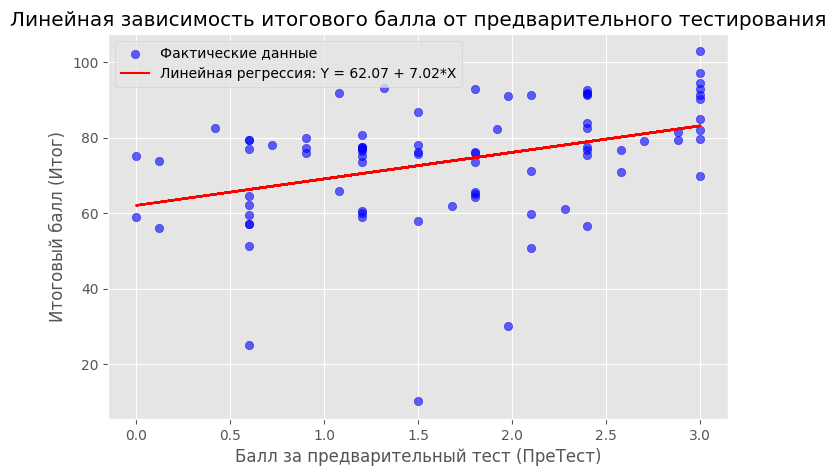

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(X, Y, alpha=0.6, label='Фактические данные', c='b')
plt.plot(X, a + b * X, color='red', label=f'Линейная регрессия: Y = {a:.2f} + {b:.2f}*X')
plt.title('Линейная зависимость итогового балла от предварительного тестирования')
plt.xlabel('Балл за предварительный тест (ПреТест)')
plt.ylabel('Итоговый балл (Итог)')
plt.legend()
plt.grid(True)
plt.show()

На графике видно:

- Синие точки: Это фактические данные, где по горизонтали (X) отложены баллы за предварительный тест, а по вертикали (Y) — итоговые баллы.
- Красная линия: Это линия линейной регрессии, которая наилучшим образом описывает зависимость между этими двумя показателями. Уравнение этой линии: Y = 62.07 + 7.02*X.


> Как видно из графика, хоть и существует общая тенденция к увеличению итогового балла с ростом балла за предварительный тест, точки достаточно рассеяны вокруг красной линии, что подтверждает ранее рассчитанный низкий R-квадрат и указывает на то, что предварительное тестирование лишь частично объясняет итоговую успеваемость.

## **3. Понятие корреляции. Оценка силы линейной зависимости**
---

Давайте еще раз построим линейную зависимость, но теперь предварительно отнормируем значения переменных X и Y.

In [15]:
print(f"Среднее значение Х= {X.mean()}, стандартное отклонение Х = {X.std()}")
print(f"Среднее значение Y= {Y.mean()}, стандартное отклонение Y = {Y.std()}")

Среднее значение Х= 1.67775, стандартное отклонение Х = 0.8688767301245317
Среднее значение Y= 73.85262499999999, стандартное отклонение Y = 15.789457686532813


In [16]:
Xn = (X - X.mean()) / X.std()
Yn = (Y - Y.mean()) / Y.std()
print(f"Среднее значение Хn= {Xn.mean().round(2)}, стандартное отклонение Хn = {Xn.std()}")
print(f"Среднее значение Yn= {Yn.mean().round(2)}, стандартное отклонение Yn = {Yn.std()}")

Среднее значение Хn= -0.0, стандартное отклонение Хn = 1.0
Среднее значение Yn= 0.0, стандартное отклонение Yn = 0.9999999999999998


In [17]:
# Perform linear regression
bn, an, r_value, p_value, std_err = linregress(Xn, Yn)

# Print the coefficients
print(f"Коэффициент an (пересечение с осью Yn): {an:.3f}")
print(f"Коэффициент bn (наклон): {bn:.3f}")

# Optionally, print R-squared for model quality
print(f"R-квадрат: {r_value**2:.3f}")

Коэффициент an (пересечение с осью Yn): 0.000
Коэффициент bn (наклон): 0.386
R-квадрат: 0.149


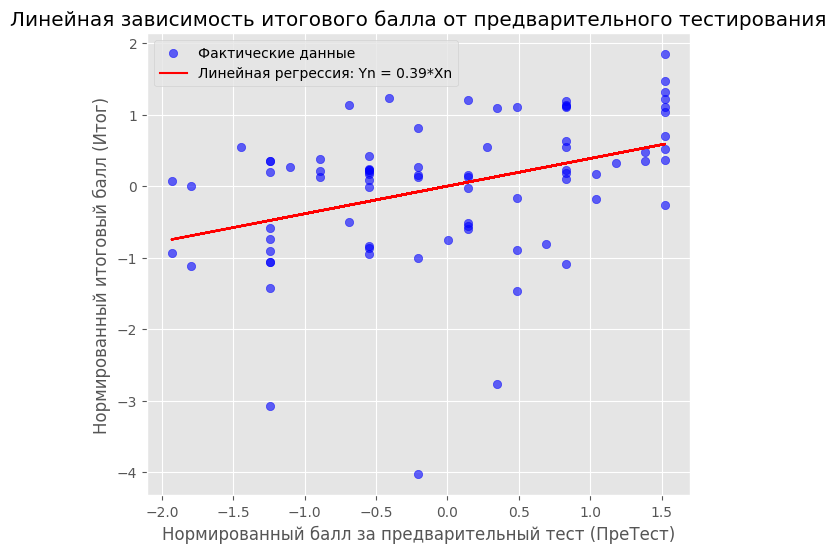

In [18]:
plt.figure(figsize=(7, 6))
plt.scatter(Xn, Yn, alpha=0.6, label='Фактические данные', c='b')
plt.plot(Xn, an + bn * Xn, color='red', label=f'Линейная регрессия: Yn = {bn:.2f}*Xn')
plt.title('Линейная зависимость итогового балла от предварительного тестирования')
plt.xlabel('Нормированный балл за предварительный тест (ПреТест)')
plt.ylabel('Нормированный итоговый балл (Итог)')
plt.legend()
plt.grid(True)
plt.show()

Т.е. после нормализации параметров X и Y приобретает вид:

$$y_{norm} = b_{n} \cdot x_{norm}$$

и при этом коэффициент b_{n} называется коэффициентом корреляции между переменными X и Y ($r_{X,Y}$) и обладает следующими свойствами:

- $r_{X,Y} = r_{Y,X}$
- $-1 \le r_{X,Y} \le 1$
- $|r_{X,Y}|=1$ - означает, что между X и Y существует строгая линейная связь (все точки лежат на одной линии)

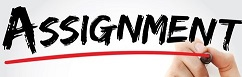

### **ЗАДАНИЕ 3.1.**
В условиях предыдущего примера зависимость нормированного y от нормированного x приняла вид:

$$y_{norm} = 0.386 \cdot x_{norm}$$

Исходя из смысла и свойств коэффициента корреляции определите каким будет коэффициент $b_n$ в модели:

$$x_{norm} = b_n \cdot y_{norm}$$

Выберите верный с вашей точки зрения ответ.

### **ОТВЕТЫ:**

### **A.** $b_n = \frac {1} {0.386}$
### **B.** $b_n = 0.386$
### **C.** $b_n = 1 - 0.386$
### **D.** $b_n = - 0.386$

-----------------------------------------------------

### Оценка силы линейной зависимости

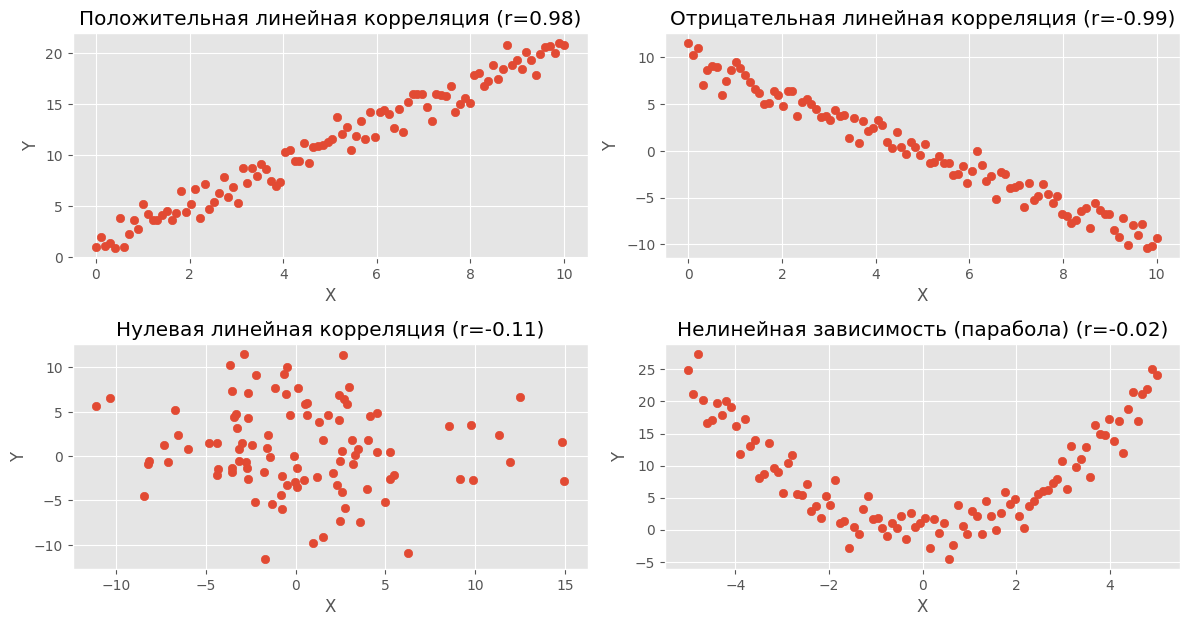


Коэффициенты корреляции Пирсона для различных видов зависимостей:
1. Сильная положительная линейная: r = 0.984
2. Сильная отрицательная линейная: r = -0.985
3. Нулевая линейная (случайный разброс): r = -0.111
4. Нелинейная (парабола): r = -0.017

Как видно из графиков и значений r:

- Коэффициент корреляции Пирсона хорошо описывает *линейную* зависимость.
- Значения близкие к +1 или -1 указывают на сильную линейную связь (положительную или отрицательную).
- Значение, близкое к 0, означает *отсутствие линейной зависимости*, но не отсутствие любой зависимости в принципе.
- Пример с параболой демонстрирует, что при наличии очевидной *нелинейной* связи коэффициент корреляции Пирсона может быть близок к нулю. Это подчеркивает, что корреляция Пирсона не улавливает нелинейные паттерны.


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Сильная положительная линейная корреляция
x1 = np.linspace(0, 10, 100)
y1 = 2 * x1 + 1 + np.random.normal(0, 1, 100)
corr1, _ = pearsonr(x1, y1)

# 2. Сильная отрицательная линейная корреляция
x2 = np.linspace(0, 10, 100)
y2 = -2 * x2 + 10 + np.random.normal(0, 1, 100)
corr2, _ = pearsonr(x2, y2)

# 3. Нулевая линейная корреляция (случайный разброс)
x3 = np.random.normal(0, 5, 100)
y3 = np.random.normal(0, 5, 100)
corr3, _ = pearsonr(x3, y3)

# 4. Нелинейная зависимость с нулевым коэффициентом корреляции Пирсона (например, парабола)
x4 = np.linspace(-5, 5, 100)
y4 = x4**2 + np.random.normal(0, 2, 100) # Парабола
corr4, _ = pearsonr(x4, y4)

plt.figure(figsize=(12, 9))

# График 1: Сильная положительная корреляция
plt.subplot(3, 2, 1)
plt.scatter(x1, y1)
plt.title(f'Положительная линейная корреляция (r={corr1:.2f})')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)

# График 2: Сильная отрицательная корреляция
plt.subplot(3, 2, 2)
plt.scatter(x2, y2)
plt.title(f'Отрицательная линейная корреляция (r={corr2:.2f})')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)

# График 3: Нулевая линейная корреляция (случайный разброс)
plt.subplot(3, 2, 3)
plt.scatter(x3, y3)
plt.title(f'Нулевая линейная корреляция (r={corr3:.2f})')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)

# График 4: Нелинейная (парабола) с близким к нулю r
plt.subplot(3, 2, 4)
plt.scatter(x4, y4)
plt.title(f'Нелинейная зависимость (парабола) (r={corr4:.2f})')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\nКоэффициенты корреляции Пирсона для различных видов зависимостей:")
print(f"1. Сильная положительная линейная: r = {corr1:.3f}")
print(f"2. Сильная отрицательная линейная: r = {corr2:.3f}")
print(f"3. Нулевая линейная (случайный разброс): r = {corr3:.3f}")
print(f"4. Нелинейная (парабола): r = {corr4:.3f}")

print("\nКак видно из графиков и значений r:\n")
print("- Коэффициент корреляции Пирсона хорошо описывает *линейную* зависимость.")
print("- Значения близкие к +1 или -1 указывают на сильную линейную связь (положительную или отрицательную).")
print("- Значение, близкое к 0, означает *отсутствие линейной зависимости*, но не отсутствие любой зависимости в принципе.")
print("- Пример с параболой демонстрирует, что при наличии очевидной *нелинейной* связи коэффициент корреляции Пирсона может быть близок к нулю. Это подчеркивает, что корреляция Пирсона не улавливает нелинейные паттерны.")

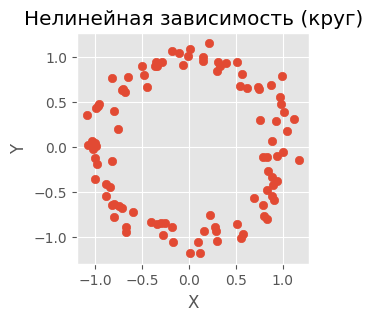

In [20]:
# Еще один пример зависимости (круг/эллипс)
t = np.linspace(0, 2 * np.pi, 100)
x5 = np.cos(t) + np.random.normal(0, 0.1, 100)
y5 = np.sin(t) + np.random.normal(0, 0.1, 100)

# График 5: Нелинейная (круг) с близким к нулю r
plt.figure(figsize=(3, 3))
plt.scatter(x5, y5)
plt.title(f'Нелинейная зависимость (круг)')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)

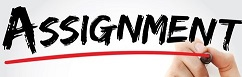

### **ЗАДАНИЕ 3.2.**
Рассмотрим пример зависимости **y** от **x** в виде окружности (см. картинку выше).

Исходя из смысла и свойств коэффициента корреляции определите каким будет коэффициент корреляции между X и Y.

Выберите наиболее близкий ответ.

### **ОТВЕТЫ:**

### **A.** $r_{X,Y} = 0.99$
### **B.** $r_{X,Y} = -0.99$
### **C.** $r_{X,Y} = 0$
### **D.** $r_{X,Y} = 0.5$

-----------------------------------------------------

## **4. Виды коэффициента корреляции**
---
- коэффициент Пирсона,
- коэффициент Спирмена,
- коэффициент Кендалла

условия применения каждого коэффициента.

Основные виды коэффициентов корреляции — Пирсона, Спирмена и Кендалла — измеряют силу и направление связи между двумя переменными (от -1 до 1). Пирсон применяется для линейной связи количественных данных с нормальным распределением, Спирмен — для монотонной связи ранговых или количественных данных, а Кендалл — для порядковых данных и малых выборок.

- Коэффициент корреляции Пирсона (Pearson's r)
Используется для оценки силы линейной связи между двумя непрерывными количественными переменными.
> Условия применения:
Данные количественные (интервальная шкала или шкала отношений).
Распределение переменных близко к нормальному.
Связь между переменными строго линейная.
Отсутствие выраженных выбросов.

- Коэффициент корреляции Спирмена (Spearman's p)
Ранговый коэффициент, оценивающий монотонную связь (не обязательно линейную).
см. https://wiki.loginom.ru/articles/rank-correlation-spearman.html


> Условия применения:
Данные могут быть количественными или порядковыми (ранговыми).
Не требует нормальности распределения (непараметрический метод).
Подходит, если связь между переменными монотонная (если одна растет, другая тоже растет или падает, но не обязательно с постоянной скоростью).
Устойчив к выбросам.

- Коэффициент корреляции Кендалла (Kendall's $τ$)
Ранговый коэффициент, определяющий степень согласованности ранжировок, основан на разнице между вероятностями согласия и несогласия пар данных.
см. https://wiki.loginom.ru/articles/rank-correlation-kendall.html

> Условия применения:
Данные порядковые (ранговые) или количественные.
Используется при небольшом объеме выборки или большом количестве одинаковых рангов (связок).
Более устойчив к ошибкам и выбросам, чем коэффициент Спирмена.

> Резюме по выбору:
- Количественные данные + нормальное распределение + линейность --> Пирсон.
- Ранги/количественные данные + нелинейная/монотонная связь --> Спирмен.
- Порядковые данные + малая выборка --> Кендалл.


Сравнение коэффициентов корреляции Спирмена и Кендалла

--- Сценарий 1: Сильная монотонная (линейная) зависимость ---
Коэффициент Пирсона: 0.999
Коэффициент Спирмена: 1.000
Коэффициент Кендалла: 1.000

--- Сценарий 2: Сильная монотонная (нелинейная) зависимость ---
Коэффициент Пирсона: 0.839
Коэффициент Спирмена: 0.964
Коэффициент Кендалла: 0.911

--- Сценарий 3: Отсутствие монотонной зависимости ---
Коэффициент Пирсона: 0.041
Коэффициент Спирмена: 0.042
Коэффициент Кендалла: 0.022



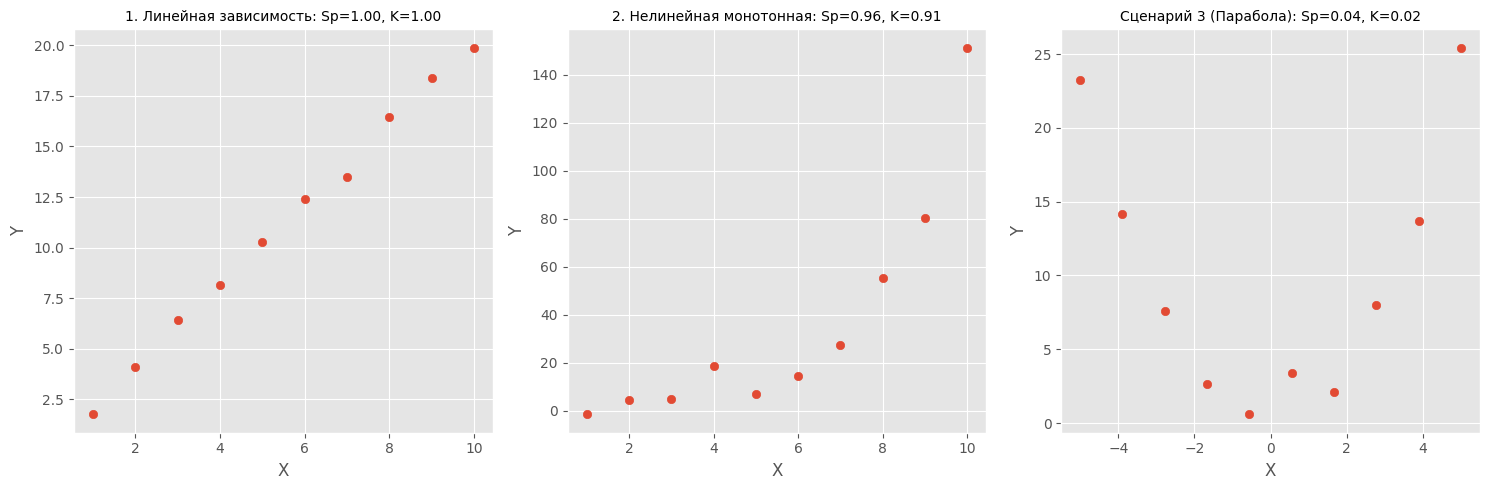


--- Общие выводы ---
1. **Коэффициент Спирмена** более чувствителен к монотонным, но не обязательно линейным, зависимостям. Он ранжирует данные и вычисляет коэффициент Пирсона для этих рангов. Обычно его значение немного выше, чем у Кендалла для одной и той же монотонной связи.
2. **Коэффициент Кендалла** также основан на рангах и измеряет степень согласованности ранжировок. Он часто предпочтителен при наличии небольших выборок или большого количества одинаковых рангов (ties), так как он более устойчив к ним и его интерпретация (вероятность согласованных пар минус вероятность несогласованных пар) более интуитивна.
3. **Оба коэффициента** будут близки к 0 при отсутствии монотонной зависимости (например, U-образная или случайный разброс).
4. При сильной линейной зависимости все три коэффициента (Пирсона, Спирмена, Кендалла) будут иметь высокие абсолютные значения, близкие к 1 или -1.


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau, pearsonr

plt.style.use('ggplot')

print("Сравнение коэффициентов корреляции Спирмена и Кендалла\n")

# --- Scenario 1: Strong Monotonic (Linear) Relationship ---
x1 = np.linspace(1, 10, 10)
y1 = 2 * x1 + np.random.normal(0, 0.5, 10)

spearman_corr1, _ = spearmanr(x1, y1)
kendall_corr1, _ = kendalltau(x1, y1)
pearson_corr1, _ = pearsonr(x1, y1)

print("--- Сценарий 1: Сильная монотонная (линейная) зависимость ---")
print(f"Коэффициент Пирсона: {pearson_corr1:.3f}")
print(f"Коэффициент Спирмена: {spearman_corr1:.3f}")
print(f"Коэффициент Кендалла: {kendall_corr1:.3f}\n")

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.scatter(x1, y1)
plt.title(f'1. Линейная зависимость: Sp={spearman_corr1:.2f}, K={kendall_corr1:.2f}', fontdict={'fontsize':10})
plt.xlabel('X')
plt.ylabel('Y')

# --- Scenario 2: Strong Monotonic (Non-linear) Relationship ---
x2 = np.linspace(1, 10, 10)
y2 = np.exp(x2/2) + np.random.normal(0, 5, 10) # Exponential relationship

spearman_corr2, _ = spearmanr(x2, y2)
kendall_corr2, _ = kendalltau(x2, y2)
pearson_corr2, _ = pearsonr(x2, y2)

print("--- Сценарий 2: Сильная монотонная (нелинейная) зависимость ---")
print(f"Коэффициент Пирсона: {pearson_corr2:.3f}")
print(f"Коэффициент Спирмена: {spearman_corr2:.3f}")
print(f"Коэффициент Кендалла: {kendall_corr2:.3f}\n")

plt.subplot(1, 3, 2)
plt.scatter(x2, y2)
plt.title(f'2. Нелинейная монотонная: Sp={spearman_corr2:.2f}, K={kendall_corr2:.2f}', fontdict={'fontsize':10})
plt.xlabel('X')
plt.ylabel('Y')

# --- Scenario 3: No Monotonic Relationship (e.g., parabolic) ---
x3 = np.linspace(-5, 5, 10)
y3 = x3**2 + np.random.normal(0, 1, 10) # Parabolic relationship

spearman_corr3, _ = spearmanr(x3, y3)
kendall_corr3, _ = kendalltau(x3, y3)
pearson_corr3, _ = pearsonr(x3, y3)

print("--- Сценарий 3: Отсутствие монотонной зависимости ---")
print(f"Коэффициент Пирсона: {pearson_corr3:.3f}")
print(f"Коэффициент Спирмена: {spearman_corr3:.3f}")
print(f"Коэффициент Кендалла: {kendall_corr3:.3f}\n")

plt.subplot(1, 3, 3)
plt.scatter(x3, y3)
plt.title(f'Сценарий 3 (Парабола): Sp={spearman_corr3:.2f}, K={kendall_corr3:.2f}', fontdict={'fontsize':10})
plt.xlabel('X')
plt.ylabel('Y')
plt.tight_layout()
plt.show()

print("\n--- Общие выводы ---")
print("1. **Коэффициент Спирмена** более чувствителен к монотонным, но не обязательно линейным, зависимостям. Он ранжирует данные и вычисляет коэффициент Пирсона для этих рангов. Обычно его значение немного выше, чем у Кендалла для одной и той же монотонной связи.")
print("2. **Коэффициент Кендалла** также основан на рангах и измеряет степень согласованности ранжировок. Он часто предпочтителен при наличии небольших выборок или большого количества одинаковых рангов (ties), так как он более устойчив к ним и его интерпретация (вероятность согласованных пар минус вероятность несогласованных пар) более интуитивна.")
print("3. **Оба коэффициента** будут близки к 0 при отсутствии монотонной зависимости (например, U-образная или случайный разброс).")
print("4. При сильной линейной зависимости все три коэффициента (Пирсона, Спирмена, Кендалла) будут иметь высокие абсолютные значения, близкие к 1 или -1.")


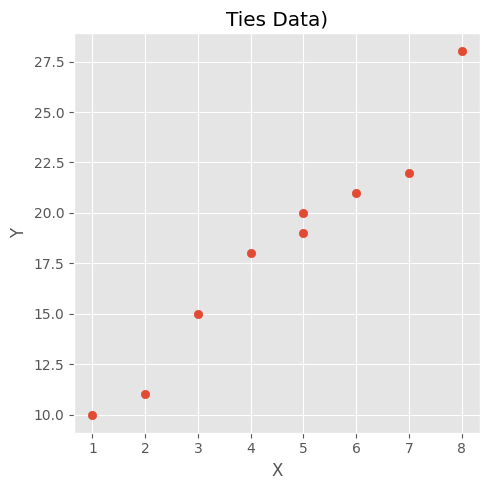

In [22]:
# --- Data with Ties ---
x4 = np.array([1, 2, 3, 4, 5, 5, 6, 7, 8])
y4 = np.array([10, 11, 15, 18, 19, 20, 21, 22, 28])

plt.figure(figsize=(5, 5))
plt.scatter(x4, y4)
plt.title(f'Ties Data)')
plt.xlabel('X')
plt.ylabel('Y')
plt.tight_layout()
plt.show()


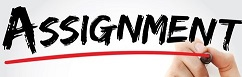

### **ЗАДАНИЕ 3.3.**
Рассмотрим пример зависимости **y** от **x** в виде змейки (см. картинку выше).

Исходя из смысла и свойств коэффициента корреляции Пирсона ($r_{X,Y}$) и Спирмена ($\rho_{X,Y}$) определите какими будут эти коэффициенты корреляции между X и Y и как они будут соотноситься между собой.

Выберите наиболее близкий ответ.

### **ОТВЕТЫ:**

### **A.** $r_{X,Y} = 0.98, \rho_{X,Y} = 0.99$
### **B.** $r_{X,Y} = 0.99, \rho_{X,Y} = 0.98$
### **C.** $r_{X,Y} = 0.5, \rho_{X,Y} = 0.8$
### **D.** $r_{X,Y} = 0.8, \rho_{X,Y} = 0.5$

-----------------------------------------------------

## **5. Роль корреляционного анализа. Примеры применения в образовании**
---
Выявление зависимостей между образовательными показателями (успеваемости, активности и т.д.)

Вернемся вновь к табличным данным, полученным в результате учебного процесса.

### ПРИМЕР корреляционного анализа
----



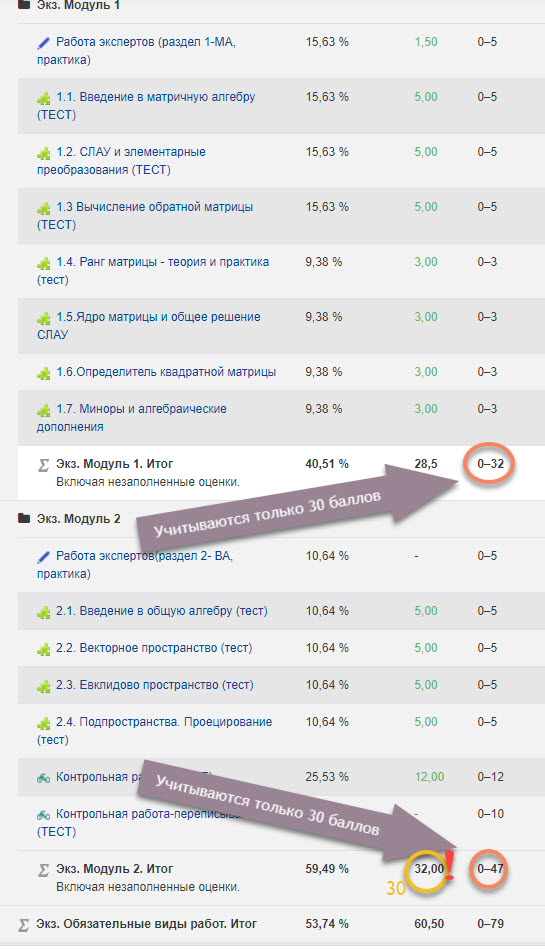

In [23]:
df.head()

,эксперт-1,1.1,1.2,1.3,1.4,1.5,1.6,1.7,2.1,2.2,...,Обязат.,ПреТест,МА-тест,Викт,РГР,Тест:4,Экзамен,Итог,ВЫБОР,Проб
0,1.5,5,5,5,3,3,3,3,5,5,...,60.50,3.00,10,3.4,6,-,20,102.90,1,14
1,1.15,5,5,5,3,3,3,3,5,5,...,57.75,3.00,8.5,3.9,-,4,20,97.15,-,14.67
2,1.6,5,5,5,3,3,3,3,5,5,...,58.93,3.00,-,3.1,5.5,4,20,94.53,1,10.67
3,3.35,5,5,5,3,3,3,3,4.83,5,...,60.48,1.32,9.5,1.9,-,2,18,93.20,-,14.07
4,0.55,5,5,5,3,3,3,3,4.83,4.75,...,57.47,3.00,9,2.5,-,3,18,92.97,0,0.17


Все перечисленные виды оцениваемых работ можно разделить на группы:

- Контрольный онлайн-тест: ПреТест. Это тест, который студент проходит сам на электронном курсе в отведенное время (1-я неделя курса). Всего 1 попытка.

- Обучающие обязательные онлайн-тесты на электронном курсе: 1.1, 1.2, 1.7 - тесты по матричной алгебре, 2.1,..., 2.4 - тесты по векторной алгебре. Это тесты, которые студенты проходят сами на электронном курсе в отведенное время (неделя) по микро-теме. Обучающие - значит, студент после прохождения теста видит свои ошибки. Имеет 5 попыток и оценку по самой лучшей попытке.

- Контрольные тесты: КР, КР-2, Экзамен. Это тесты на э-курсе, которые студенты проходят в аудитории в присутствии преподавателя.

Баллы за вышеперечисленные виды работ образуют сумму баллов за "Обязательные виды работ".

- Дополнительные обучающие онлайн-тесты: МА-тест, Тест:4 - тесты по разделу. Это итоговые тесты с ограниченным временем прохождения. 5 попыток. Оценка по самой лучшей. Студееты проходят сами в любое время до завершения семестра.

- Баллы за доп. расчетно-графическую работу (РГР). Самостоятельно выполняемая работа с индивидуальными исходными данными (по фракталам).

- Баллы за Викторины, т.е. блиц-опросы на лекциях.

- Баллы за работу экспертом (объяснение решение задач другимм студентам).

Эти три вида работ образуют доп. (необязательные) виды работ. Баллы за них засчитываются только если студент набрал 67% от максимума за обязательные виды работ.


Нас может интересовать вопрос: какой из видов работ больше всего оказывает влияние на итоговую сумму баллов.

Выполним корреляционный анализ.
Используем следующие столбцы из df для анализа:




In [24]:
df.columns

Index(['эксперт-1', '1.1', '1.2', '1.3', '1.4', '1.5', '1.6', '1.7', '2.1',
       '2.2', '2.3', '2.4', 'КР', 'КР-2', 'Обязат.', 'ПреТест', 'МА-тест',
       'Викт', 'РГР', 'Тест:4', 'Экзамен', 'Итог', 'ВЫБОР', 'Проб'],
      dtype='object')

In [25]:
mandatory_online_works = ['1.1', '1.2', '1.3', '1.4', '1.5', '1.6', '1.7', '2.1', '2.2', '2.3', '2.4']
additional_works = ['эксперт-1', 'ПреТест', 'МА-тест', 'Викт', 'РГР', 'Тест:4']
classwork = [ 'КР', 'КР-2', 'Экзамен']
goal_features = ['Обязат.','Итог']

In [26]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr, kendalltau
import numpy as np

# преобразуем все исследуемые параметры из строк в числа, пропуски обозначаем NaN
all_relevant_columns = mandatory_online_works + classwork + goal_features + additional_works
for col in all_relevant_columns:
    if col in df_filtered.columns and df_filtered[col].dtype == 'object':
        df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')

# Print info about the dataframe after numeric conversion to see NaN counts
print("df_filtered info after numeric conversion:\n")
df_filtered[all_relevant_columns].info()
print("\n")

correlation_results = []

for goal in goal_features:
    print(f"Рассчитываем корреляцию работ с {goal}...\n")
    for work in mandatory_online_works:
        if work in df_filtered.columns and goal in df_filtered.columns:
            # Create a temporary DataFrame for the current pair of columns, dropping NaNs specific to this pair
            temp_df = df_filtered[[work, goal]].dropna()

            if len(temp_df) < 2: # Need at least 2 data points for correlation
                pearson_val, spearman_val, kendall_val = np.nan, np.nan, np.nan
            else:
                x_data = temp_df[work]
                y_data = temp_df[goal]

                # Check if there is variation in the data to avoid std dev of 0
                if x_data.std() == 0 or y_data.std() == 0:
                    pearson_val, spearman_val, kendall_val = np.nan, np.nan, np.nan
                else:
                    pearson_val, _ = pearsonr(x_data, y_data)
                    spearman_val, _ = spearmanr(x_data, y_data)
                    kendall_val, _ = kendalltau(x_data, y_data)

            correlation_results.append({
                'Goal Feature': goal,
                'Work Type': work,
                'Pearson_r': pearson_val,
                'Spearman_rho': spearman_val,
                'Kendall_tau': kendall_val
            })
            if np.isnan(pearson_val): # Only print if a value was computed
                print(f"  {work}: Correlation not calculated due to insufficient data or lack of variance.")
    # print("\n")

results_df = pd.DataFrame(correlation_results)

print("Overall Correlation Results (Pearson, Spearman, Kendall):\n")
# Filter out rows where all correlation values are NaN before printing the markdown table
results_df_cleaned = results_df.dropna(subset=['Pearson_r', 'Spearman_rho', 'Kendall_tau'], how='all')
print(results_df_cleaned.round(3).to_markdown(index=False))

/tmp/ipykernel_759/2852758308.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')


df_filtered info after numeric conversion:

<class 'pandas.core.frame.DataFrame'>
Index: 80 entries, 0 to 98
Data columns (total 22 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   1.1        80 non-null     float64
 1   1.2        79 non-null     float64
 2   1.3        80 non-null     float64
 3   1.4        80 non-null     float64
 4   1.5        79 non-null     float64
 5   1.6        77 non-null     float64
 6   1.7        79 non-null     float64
 7   2.1        79 non-null     float64
 8   2.2        78 non-null     float64
 9   2.3        77 non-null     float64
 10  2.4        77 non-null     float64
 11  КР         77 non-null     float64
 12  КР-2       6 non-null      float64
 13  Экзамен    73 non-null     float64
 14  Обязат.    80 non-null     float64
 15  Итог       80 non-null     float64
 16  эксперт-1  33 non-null     float64
 17  ПреТест    80 non-null     float64
 18  МА-тест    17 non-null     float64
 19  Викт       79

Ранжируем результаты по силе линейной связи

In [27]:
print("Overall Correlation Results (Pearson, Spearman, Kendall) - Ranked by Pearson_r:\n")
# Sort the cleaned results DataFrame by Pearson_r in descending order
sorted_by_pearson = results_df_cleaned.sort_values(by=['Goal Feature', 'Pearson_r'], ascending=False)
print(sorted_by_pearson.round(3).to_markdown(index=False))

Overall Correlation Results (Pearson, Spearman, Kendall) - Ranked by Pearson_r:

| Goal Feature   |   Work Type |   Pearson_r |   Spearman_rho |   Kendall_tau |
|:---------------|------------:|------------:|---------------:|--------------:|
| Обязат.        |         2.2 |       0.756 |          0.664 |         0.509 |
| Обязат.        |         2.3 |       0.752 |          0.739 |         0.581 |
| Обязат.        |         1.4 |       0.648 |          0.511 |         0.414 |
| Обязат.        |         1.3 |       0.638 |          0.699 |         0.546 |
| Обязат.        |         2.4 |       0.601 |          0.609 |         0.467 |
| Обязат.        |         1.2 |       0.594 |          0.56  |         0.444 |
| Обязат.        |         1.5 |       0.575 |          0.638 |         0.507 |
| Обязат.        |         2.1 |       0.516 |          0.546 |         0.417 |
| Обязат.        |         1.1 |       0.507 |          0.617 |         0.487 |
| Обязат.        |         1.7 |       

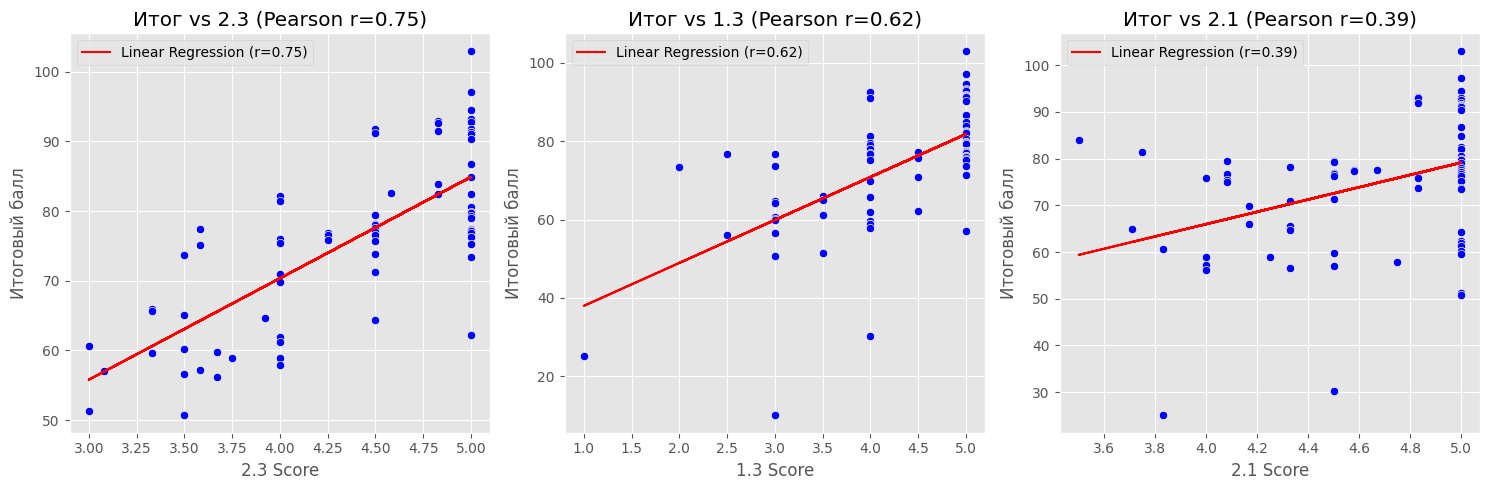

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

goal_feature = 'Итог'
work_types_to_plot = ['2.3', '1.3', '2.1']

plt.figure(figsize=(15, 5))

for i, work_type in enumerate(work_types_to_plot):
    # Drop NaNs for the current pair of columns
    temp_df = df_filtered[[work_type, goal_feature]].dropna()

    if len(temp_df) < 2:
        print(f"Not enough data points for {work_type} vs {goal_feature} to plot.")
        continue

    X_plot = temp_df[work_type]
    Y_plot = temp_df[goal_feature]

    # Calculate linear regression
    slope, intercept, r_value, p_value, std_err = linregress(X_plot, Y_plot)

    plt.subplot(1, len(work_types_to_plot), i + 1)
    sns.scatterplot(x=X_plot, y=Y_plot, c='blue')
    plt.plot(X_plot, intercept + slope * X_plot, color='red', label=f'Linear Regression (r={r_value:.2f})')
    plt.title(f'Итог vs {work_type} (Pearson r={r_value:.2f})')
    plt.xlabel(f'{work_type} Score')
    plt.ylabel('Итоговый балл')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [28]:
df_filtered.describe()

,эксперт-1,1.1,1.2,1.3,1.4,1.5,1.6,1.7,2.1,2.2,...,КР,КР-2,Обязат.,ПреТест,МА-тест,Викт,РГР,Тест:4,Экзамен,Итог
count,33.000000,80.000000,79.000000,80.000000,80.000000,79.000000,77.000000,79.000000,79.000000,78.000000,...,77.000000,6.000000,80.000000,80.000000,17.000000,79.000000,12.000000,45.000000,73.000000,80.000000
mean,1.590909,4.706250,4.334051,4.275000,2.763750,2.701266,2.836364,2.802532,4.661266,4.416154,...,8.661299,8.011667,50.934750,1.677750,8.723529,2.320253,5.925000,2.711111,16.065342,73.852625
std,0.953649,0.409103,0.756214,0.896194,0.431437,0.402076,0.281868,0.412924,0.418604,0.718099,...,1.998274,1.243518,8.156373,0.868877,1.201967,0.931690,2.597945,1.575699,3.147592,15.789458
min,0.500000,3.500000,1.000000,1.000000,1.200000,1.500000,1.800000,0.600000,3.500000,1.080000,...,3.460000,5.940000,8.700000,0.000000,5.750000,0.000000,0.100000,0.000000,1.330000,10.200000
25%,1.000000,4.500000,4.000000,4.000000,2.625000,2.400000,2.700000,2.700000,4.330000,4.000000,...,7.200000,7.512500,47.837500,1.080000,8.500000,1.750000,5.125000,2.000000,14.670000,64.585000
50%,1.450000,5.000000,4.500000,4.750000,3.000000,3.000000,3.000000,3.000000,4.830000,4.500000,...,8.700000,8.400000,52.580000,1.740000,9.000000,2.500000,6.000000,3.000000,16.900000,76.705000
75%,2.000000,5.000000,5.000000,5.000000,3.000000,3.000000,3.000000,3.000000,5.000000,5.000000,...,10.500000,8.560000,56.230000,2.400000,9.500000,3.100000,6.625000,4.000000,18.000000,82.427500
max,4.800000,5.000000,5.000000,5.000000,3.000000,3.000000,3.000000,3.000000,5.000000,5.000000,...,12.000000,9.500000,60.500000,3.000000,10.000000,3.900000,10.000000,5.000000,20.000000,102.900000


### Выводы
---

- Самое большое влияние на сумму баллов за обязательные виды работ оказала работа по темам 2.2 (Векторное пространство) и 2.3 (Евклидово пространство). Несмотря на то, что финальная тема 2.4. (Подпространства), она оказала меньшее влияние на итоговую сумму баллов.

- На итог работы на курсе самое большое влияние имеют работы по тем же темам 2.2, 2.3 и по теме 1,3 (Вычисление обратной матрицы). Возможно, что это самые емкие, самые сложные, самые интегральные темы, которые требуют знания большинства тем.

- Меньше всего на итог повлияла тема 2.1 (абстрактная общая алгебра) и тема 1.7 (Миноры и алгебраические дополнения), так как она тоже более теоретическая, чем практическая (больше на понимание "почему", чем на применение).


## ОБЩИЕ ВЫВОДЫ
---

- Корреляционный анализ, в основе которого лежит построение простой линейной модели парной связи, может выявить только линейную связь или нелинейную монотонную.

- $|r_{X,Y}| ≈ 1$ означает строгую линейную связь между параметрами.

- $|r_{X,Y}| ≈ 0$ означает отсутствие ТОЛЬКО линейной связи между параметрами.

- Все коэффициенты корреляции мало отличаются друг от друга, если вычисляются для оценки связи между числовыми параметрами.

- Ранговые коэффициенты Спирмена и Кендала могут вычисляться для порядковых величин.

- Коэффициент Спирмена, как и Кендала, показывает силу не только линейной связи, но и монотонной нелинейной, поэтому, полезно сравнивать значения коэффициентов Пирсона и Спирмена.

- Коэффициент ранговой корреляции Кендала также как и Спирмена основывается на рангах значений переменных, но чаще используется для малых выборок.
